<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
#!pip install pandas
#!pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)


In [4]:
df.tail()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65432,65433,I am a developer by profession,18-24 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","On the job training;School (i.e., University, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,65435,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,65436,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65436,65437,I code primarily as a hobby,18-24 years old,"Student, full-time",NaN,Apples,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [5]:
#let's get a specific dataset for this analysis, without missing values
df_age_js6 = df[['Age', 'JobSatPoints_6']].dropna()
df_age_js6.shape

(29450, 2)

+++we still have a good sample...

In [6]:
#Age is a categorical variable whose values are actually  age ranges. In order to plot  scatter plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and convert the values in the other rows to the age range mean value.
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_age_js6_1 = df_age_js6[df_age_js6['Age'] != 'Prefer not to say'].copy()
df_age_js6_1.loc[:, 'Age'] = df_age_js6_1['Age'].map(numerical_ages)
df_age_js6_1.head()

,Age,JobSatPoints_6
1,39.5,0.0
10,39.5,25.0
12,39.5,30.0
15,49.5,0.0
18,29.5,60.0


In [7]:
df_age_js6_1.dtypes

Age                object
JobSatPoints_6    float64
dtype: object

In [8]:
df_age_js6_1['Age'] = df_age_js6_1['Age'].astype(float)

In [9]:
df_age_js6_1.dtypes

Age               float64
JobSatPoints_6    float64
dtype: object

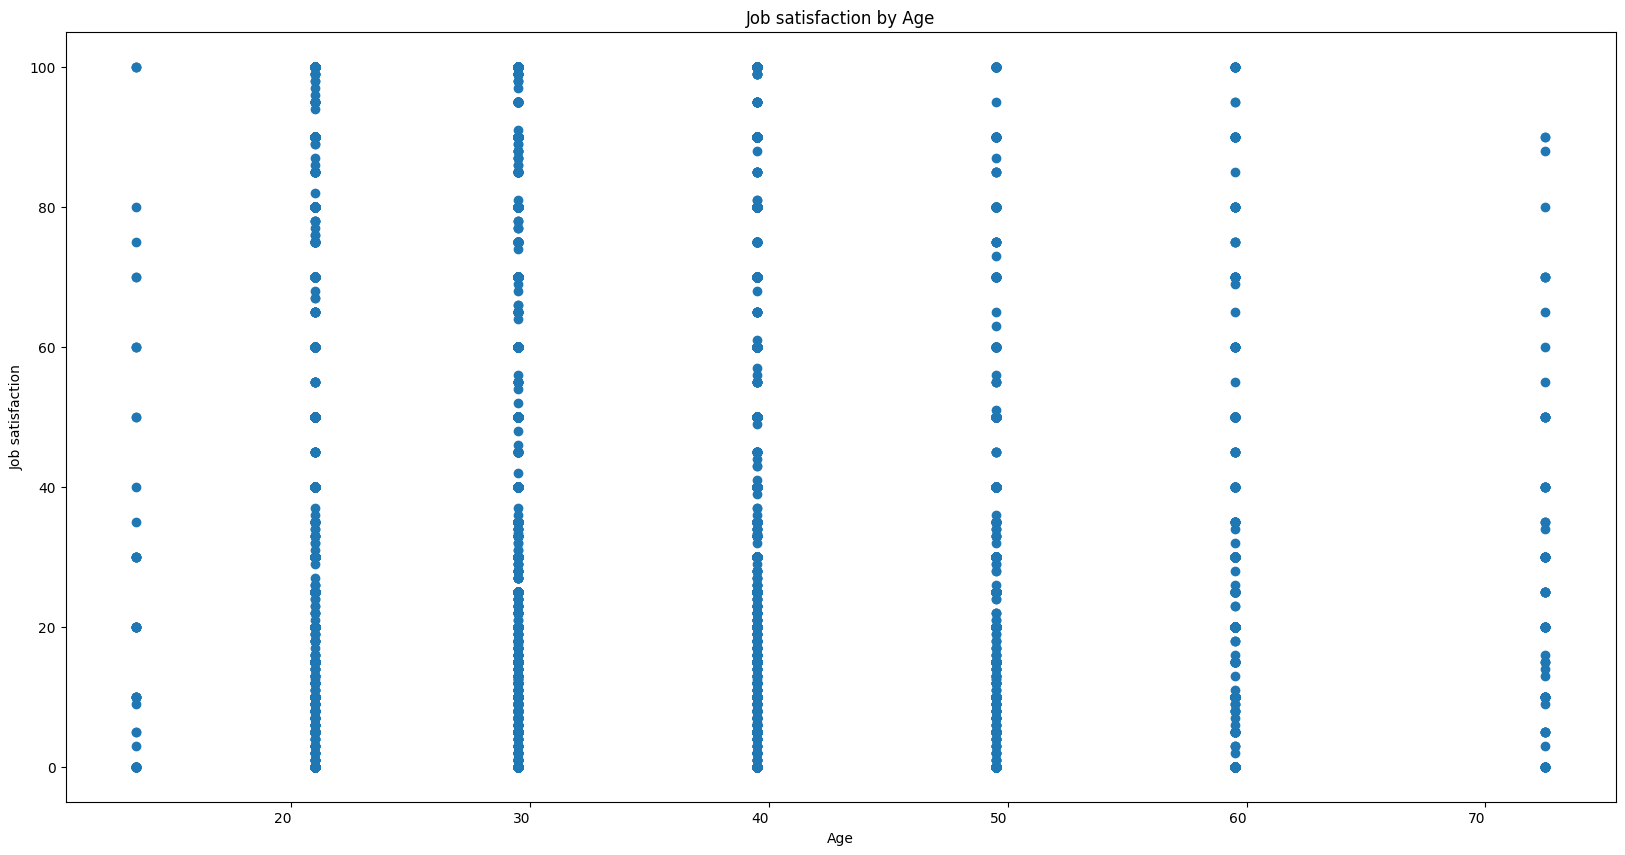

In [10]:
#let's plot the scatter plot
#scatter plot - Age and JobSatPoints_6
plt.figure(figsize=(20, 10))
plt.scatter(df_age_js6_1['Age'], df_age_js6_1['JobSatPoints_6'])
plt.xticks(rotation=0, ha='right')
plt.title('Job satisfaction by Age')
plt.xlabel('Age')
plt.ylabel('Job satisfaction')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

+++We can see that there is no meaningful relationship between job satisfaction and age

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [11]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_js6 = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()
print(df_ccy_js6.shape)
df_ccy_js6.head()

(16185, 2)


,ConvertedCompYearly,JobSatPoints_6
72,7322.0,65.0
379,91295.0,0.0
389,110000.0,20.0
392,161044.0,30.0
398,195000.0,30.0


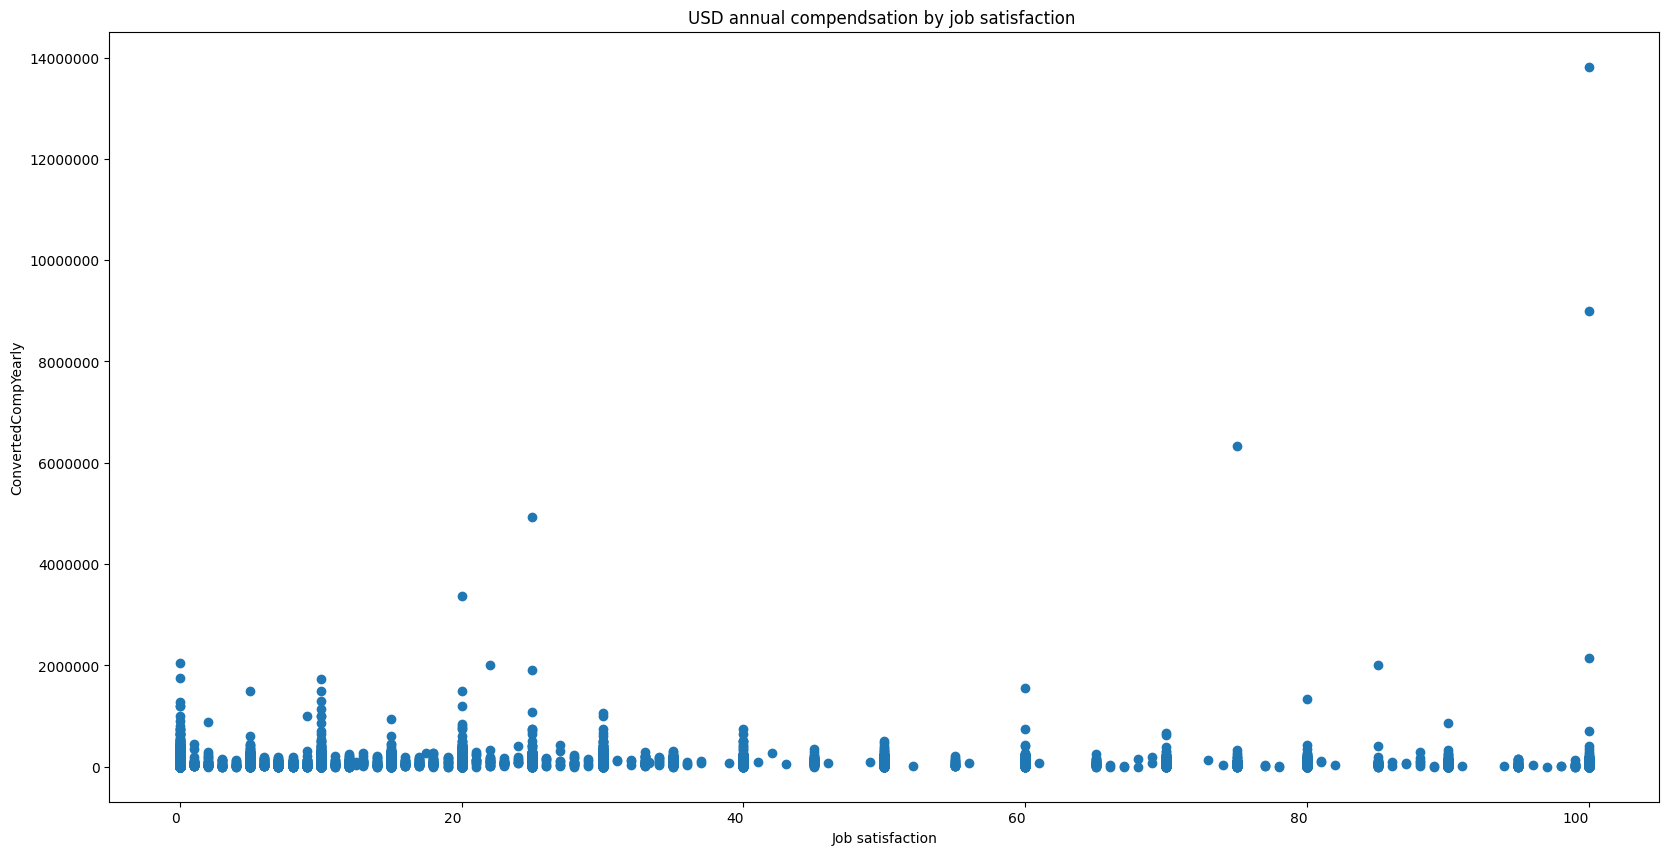

In [12]:
#let's plot the scatter plot
#scatter plot - JobSatPoints_6 and ConvertedCompYearly
plt.figure(figsize=(20, 10))
plt.scatter(df_ccy_js6['JobSatPoints_6'], df_ccy_js6['ConvertedCompYearly'])
plt.xticks(rotation=0, ha='right')
plt.ylabel('ConvertedCompYearly')
plt.xlabel('Job satisfaction')
plt.title('USD annual compendsation by job satisfaction ')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

###we can have a better view if we exclude ConvertedCompYearly outliers

In [13]:
df_ccy_js6.describe()

,ConvertedCompYearly,JobSatPoints_6
count,1.618500e+04,16185.000000
mean,8.577514e+04,25.105968
std,1.717094e+05,26.503119
min,1.000000e+00,0.000000
25%,3.356800e+04,5.000000
50%,6.573300e+04,20.000000
75%,1.080020e+05,30.000000
max,1.381802e+07,100.000000


In [14]:
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.080020e+05
q1 = 3.356800e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  74434.0
Upper bound for outliers =  219653.0
Lower bound for outliers =  -78083.0


###As the lower bound is negative, we do not have to worry about it

In [15]:
df_ccy_js6_no_outliers = df_ccy_js6[df_ccy_js6['ConvertedCompYearly']<=out_upper]
df_ccy_js6_no_outliers.shape

(15507, 2)

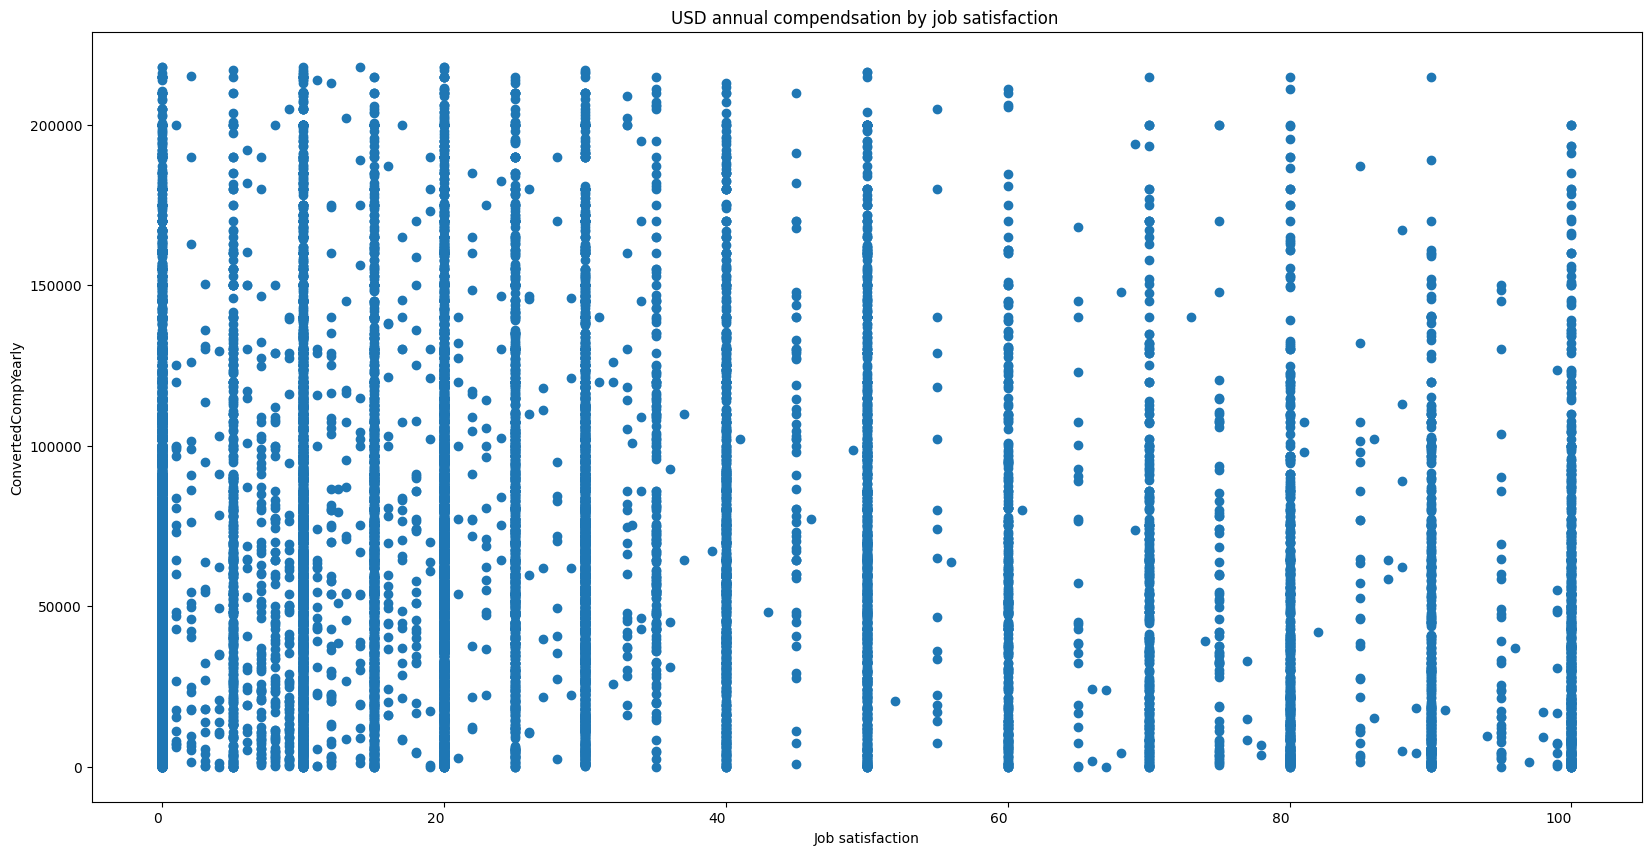

In [16]:
#let's plot the scatter plot without outliers
#scatter plot - JobSatPoints_6 and ConvertedCompYearly
plt.figure(figsize=(20, 10))
plt.scatter(df_ccy_js6_no_outliers['JobSatPoints_6'], df_ccy_js6_no_outliers['ConvertedCompYearly'])
plt.xticks(rotation=0, ha='right')
plt.ylabel('ConvertedCompYearly')
plt.xlabel('Job satisfaction')
plt.title('USD annual compendsation by job satisfaction ')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

+++We can see that there is no meaningful relationship between job satisfaction and USD annual compensation

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


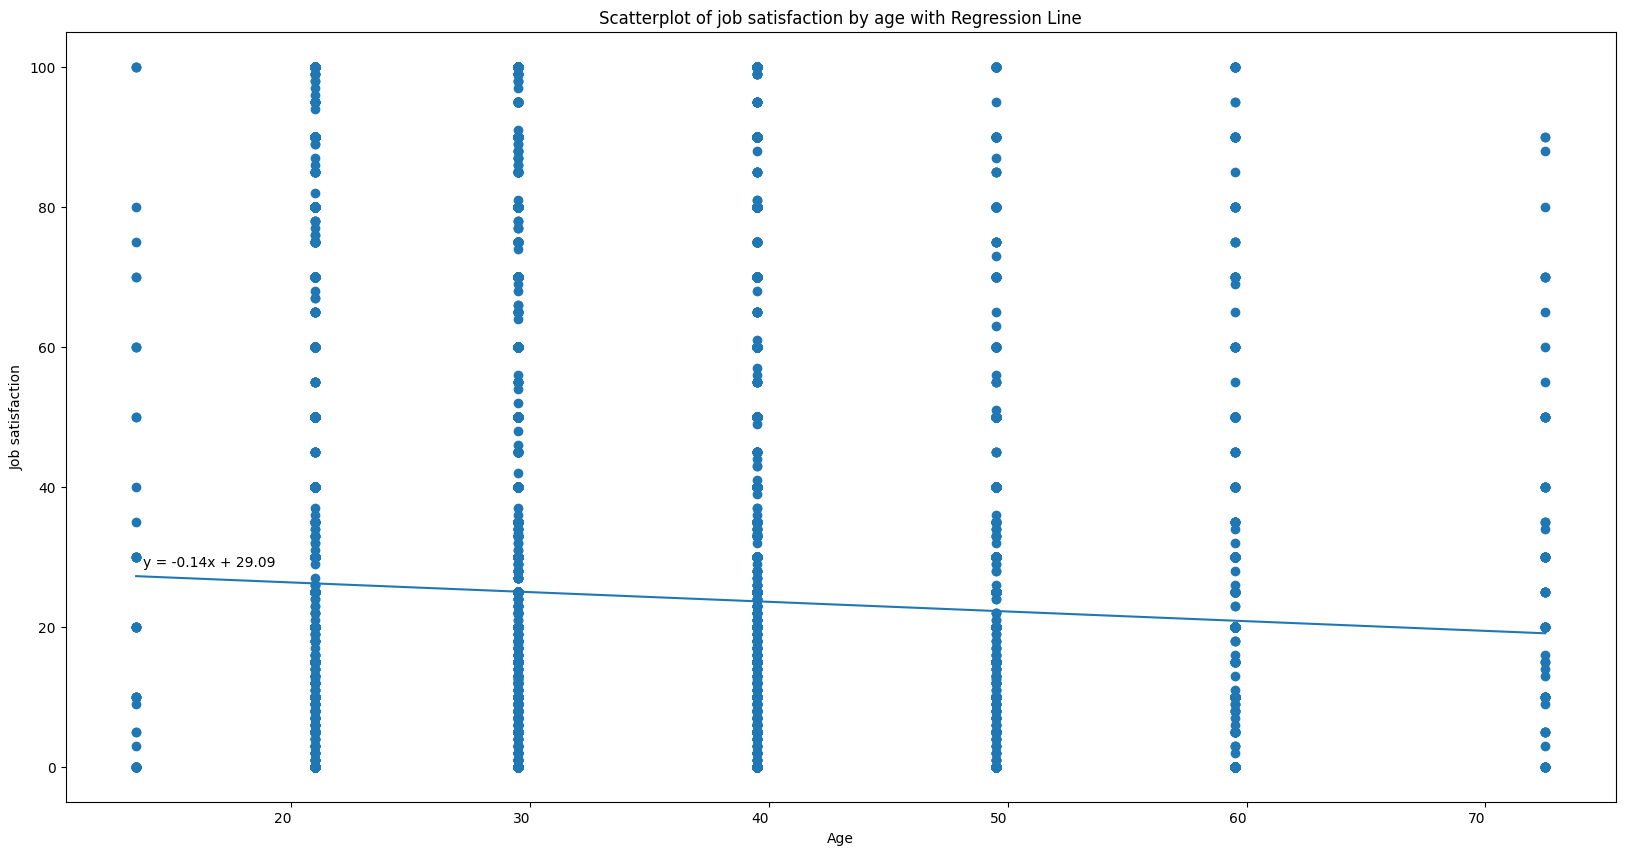

In [17]:
x = df_age_js6_1['Age']
y = df_age_js6_1['JobSatPoints_6']

# Scatter plot
plt.figure(figsize=(20, 10))
plt.scatter(x, y)

# Fit a linear regression line (y = m*x + b)
m, b = np.polyfit(x, y, 1)

# Plot regression line
x_sorted = np.sort(x)
plt.plot(x_sorted, m*x_sorted + b)

# Equation text
equation = f'y = {m:.2f}x + {b:.2f}'

# Place text on plot
plt.text(
    0.05, 0.32, equation,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top')

plt.xlabel('Age')
plt.ylabel('Job satisfaction')
plt.title('Scatterplot of job satisfaction by age with Regression Line')
plt.xticks(rotation=0, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [18]:
#let's get a specific dataset for this analysis, without missing values
df_age_ycp = df[['Age', 'YearsCodePro']].dropna()
df_age_ycp.shape

(51610, 2)

In [19]:
#Age is a categorical variable whose values are actually  age ranges. In order to plot  scatter plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and convert the values in the other rows to the age range mean value.
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_age_ycp_1 = df_age_ycp[df_age_ycp['Age'] != 'Prefer not to say'].copy()
df_age_ycp_1.loc[:, 'Age'] = df_age_ycp_1['Age'].map(numerical_ages)
df_age_ycp_1['Age'] = df_age_ycp_1['Age'].astype(float)
df_age_ycp_1.head()

,Age,YearsCodePro
1,39.5,17
2,49.5,27
6,39.5,7
9,39.5,11
11,49.5,25


In [20]:
df_age_ycp_1.dtypes

Age             float64
YearsCodePro     object
dtype: object

In [21]:
df_age_ycp_1['YearsCodePro'].unique()

array(['17', '27', '7', '11', '25', '12', '10', '3', 'Less than 1 year',
       '18', '37', '15', '20', '6', '16', '8', '14', '4', '45', '1', '24',
       '2', '29', '5', '30', '26', '9', '33', '13', '35', '23', '22',
       '31', '19', '21', '28', '34', '32', '40', '50', '39', '44', '42',
       '41', '36', '38', 'More than 50 years', '43', '47', '48', '46',
       '49'], dtype=object)

In [22]:
#let's convert YearsCodePro to numeric
mapping = {'Less than 1 year': 0.0, 'More than 50 years': 50.0}
df_age_ycp_1['YearsCodePro'] = df_age_ycp_1['YearsCodePro'].replace(mapping).astype(float)
print(df_age_ycp_1['YearsCodePro'].unique())
df_age_ycp_1.head()

[17. 27.  7. 11. 25. 12. 10.  3.  0. 18. 37. 15. 20.  6. 16.  8. 14.  4.
 45.  1. 24.  2. 29.  5. 30. 26.  9. 33. 13. 35. 23. 22. 31. 19. 21. 28.
 34. 32. 40. 50. 39. 44. 42. 41. 36. 38. 43. 47. 48. 46. 49.]


,Age,YearsCodePro
1,39.5,17.0
2,49.5,27.0
6,39.5,7.0
9,39.5,11.0
11,49.5,25.0


In [23]:
df_age_ycp_1.dtypes

Age             float64
YearsCodePro    float64
dtype: object

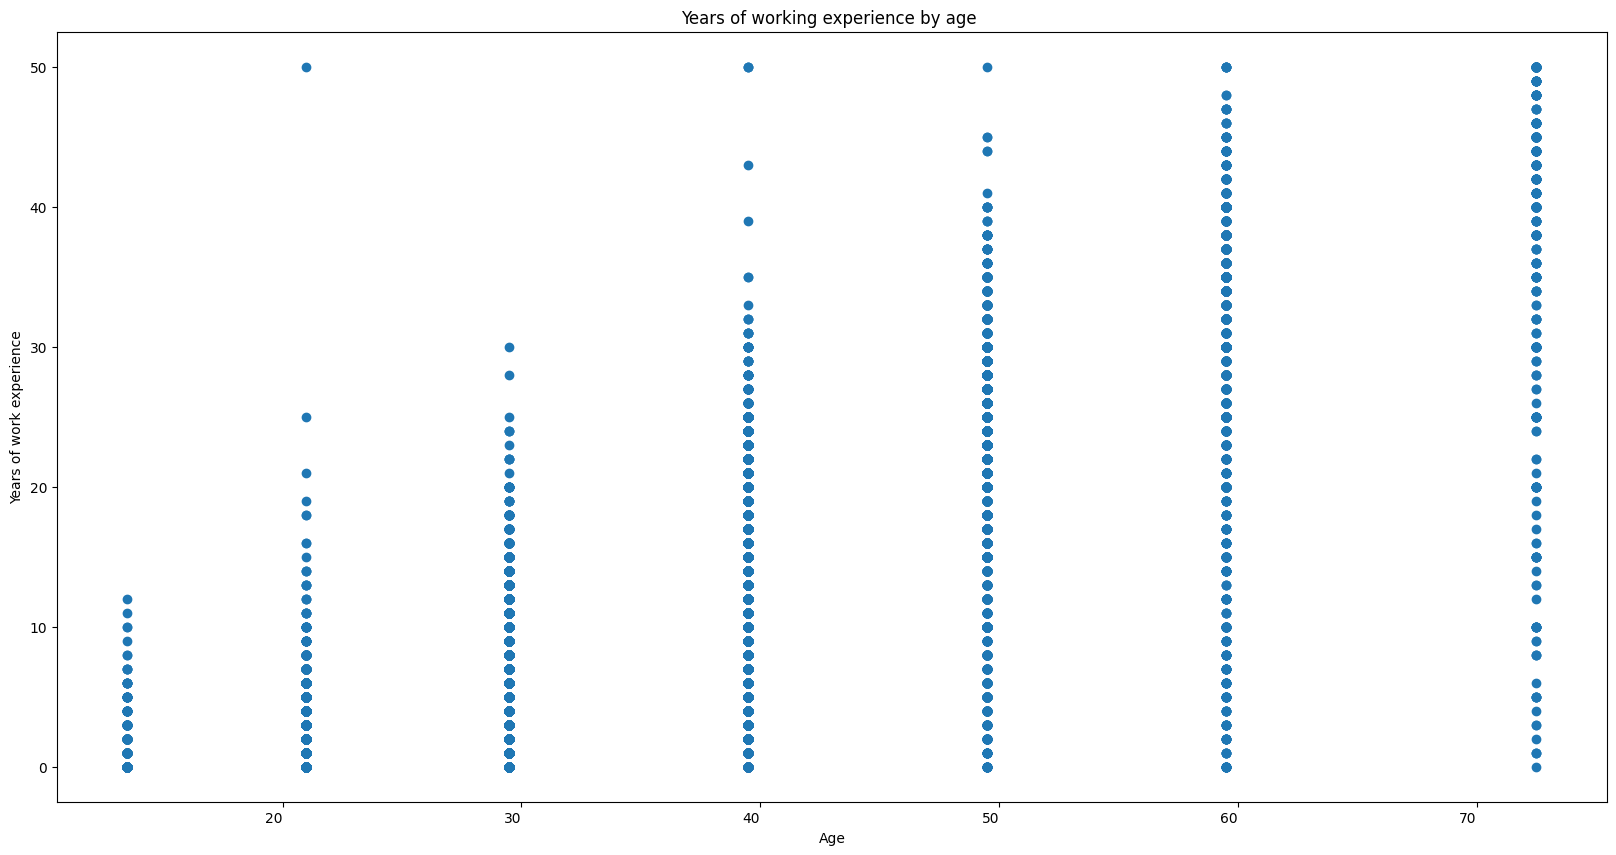

In [25]:
#let's plot the scatter plot
#scatter plot - Age and YearsCodePro
plt.figure(figsize=(20, 10))
plt.scatter(df_age_ycp_1['Age'], df_age_ycp_1['YearsCodePro'])
plt.xticks(rotation=0, ha='right')
plt.ylabel('Years of work experience')
plt.xlabel('Age')
plt.title('Years of working experience by age ')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [26]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_js6_age = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].dropna()
print(df_ccy_js6_age.shape)
df_ccy_js6_age.head()

(16185, 3)


,ConvertedCompYearly,JobSatPoints_6,Age
72,7322.0,65.0,18-24 years old
379,91295.0,0.0,35-44 years old
389,110000.0,20.0,25-34 years old
392,161044.0,30.0,35-44 years old
398,195000.0,30.0,45-54 years old


In [27]:
#Age is a categorical variable whose values are actually  age ranges. In order to plot  scatter plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and convert the values in the other rows to the age range mean value.
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_ccy_js6_age_1 = df_ccy_js6_age[df_ccy_js6_age['Age'] != 'Prefer not to say'].copy()
df_ccy_js6_age_1.loc[:, 'Age'] = df_ccy_js6_age_1['Age'].map(numerical_ages)
df_ccy_js6_age_1['Age'] = df_ccy_js6_age_1['Age'].astype(float)
df_ccy_js6_age_1.head()

,ConvertedCompYearly,JobSatPoints_6,Age
72,7322.0,65.0,21.0
379,91295.0,0.0,39.5
389,110000.0,20.0,29.5
392,161044.0,30.0,39.5
398,195000.0,30.0,49.5


In [28]:
df_ccy_js6_age_1.dtypes

ConvertedCompYearly    float64
JobSatPoints_6         float64
Age                    float64
dtype: object

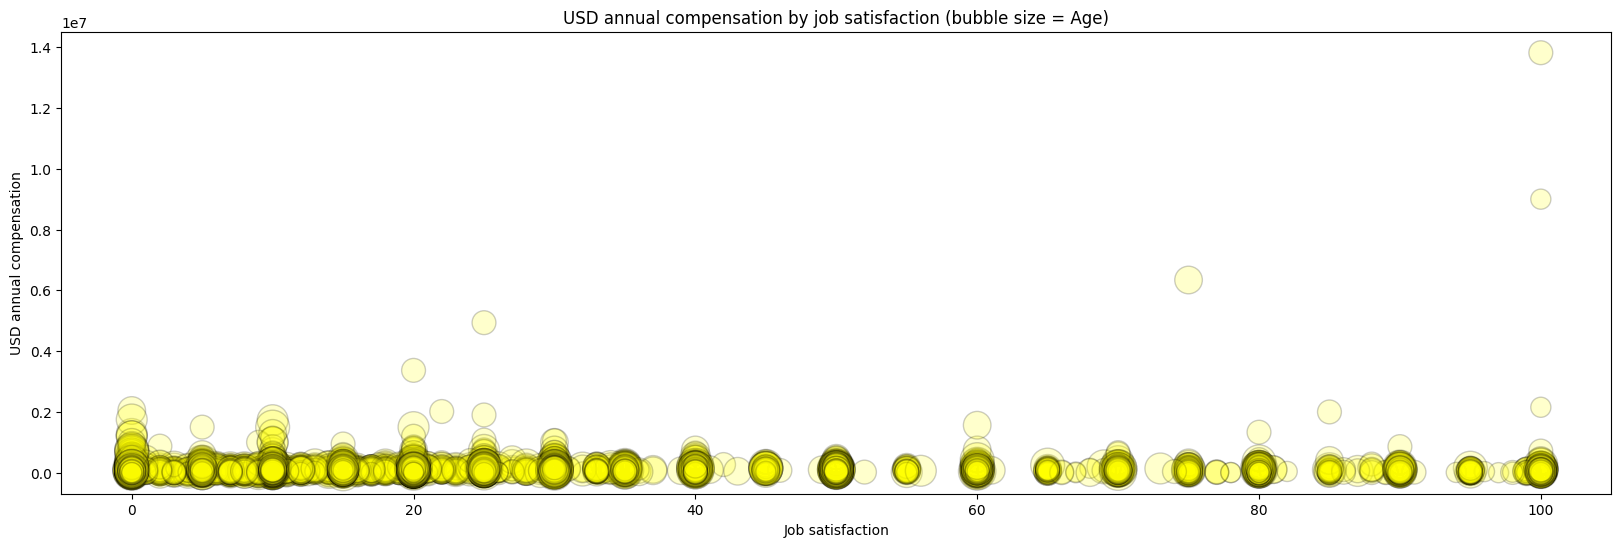

In [29]:
#let's plot the bubble chart
plt.figure(figsize=(20, 6))

# Scatter plot
plt.scatter(
    x=df_ccy_js6_age_1['JobSatPoints_6'],
    y=df_ccy_js6_age_1['ConvertedCompYearly'],
    s=df_ccy_js6_age_1['Age'] *10,
    alpha=0.2,
    color='yellow',
    edgecolors='black')

plt.title('USD annual compensation by job satisfaction (bubble size = Age)')
plt.xlabel('Job satisfaction')
plt.ylabel('USD annual compensation')
plt.show()

###We can do a better analysis by excluding ConvertedCompYearly outliers

In [30]:
df_ccy_js6_age_1['ConvertedCompYearly'].describe()

count    1.617700e+04
mean     8.574844e+04
std      1.717437e+05
min      1.000000e+00
25%      3.356800e+04
50%      6.566500e+04
75%      1.080000e+05
max      1.381802e+07
Name: ConvertedCompYearly, dtype: float64

In [31]:
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.080000e+05
q1 = 3.356800e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  74432.0
Upper bound for outliers =  219648.0
Lower bound for outliers =  -78080.0


In [32]:
df_ccy_js6_age_1_no_outliers = df_ccy_js6_age_1[df_ccy_js6_age_1['ConvertedCompYearly']<=out_upper]
df_ccy_js6_age_1_no_outliers.shape

(15500, 3)

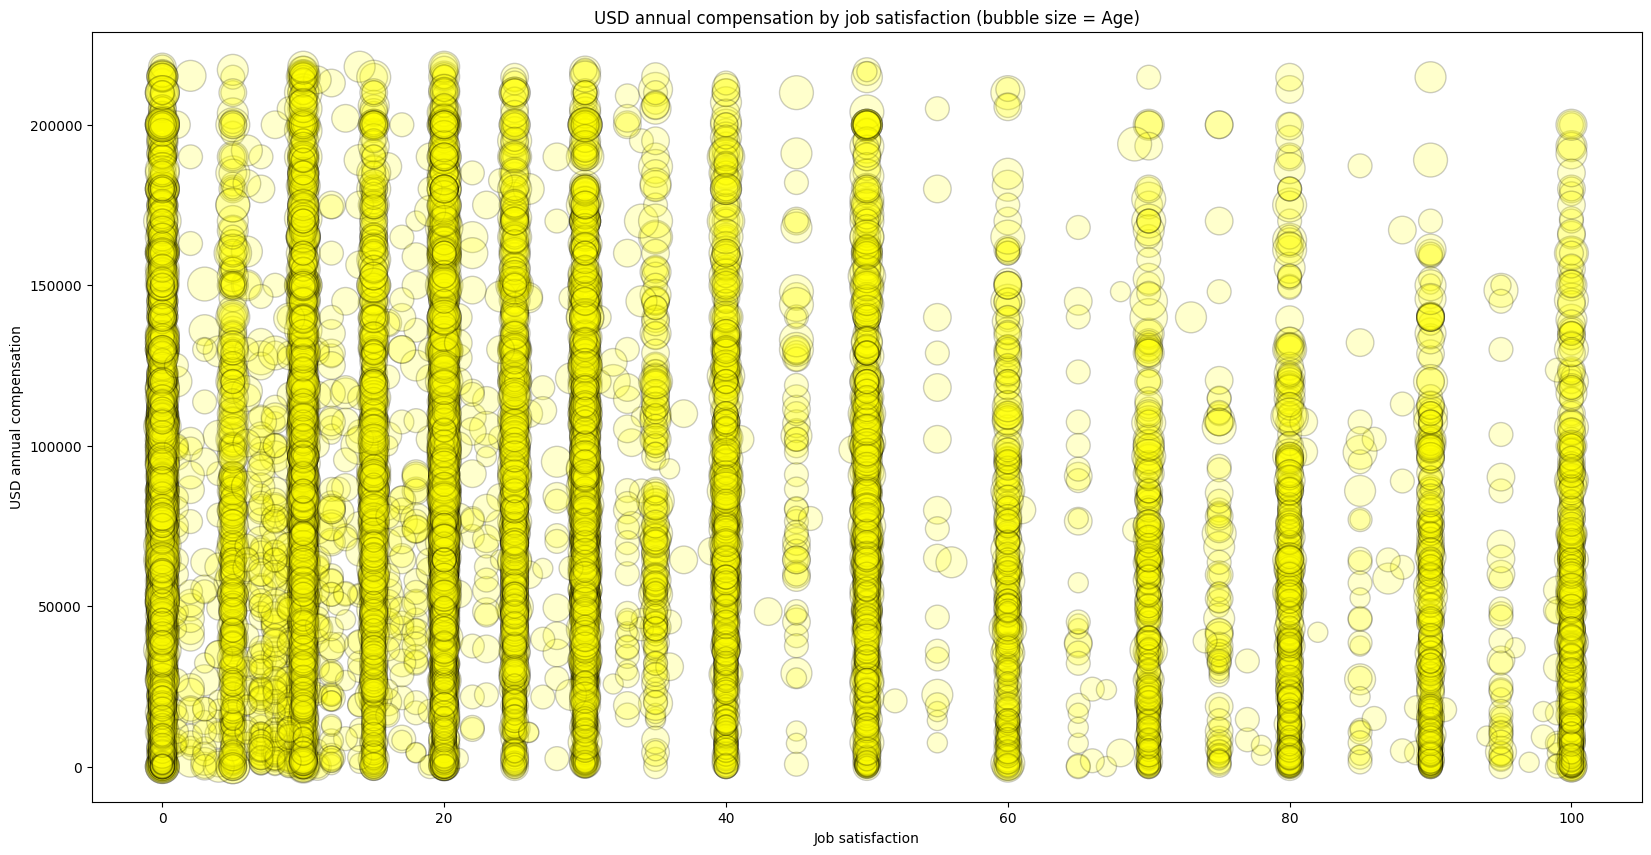

In [33]:
#let's plot the bubble chart excluding outliers
plt.figure(figsize=(20, 10))

# Scatter plot
plt.scatter(
    x=df_ccy_js6_age_1_no_outliers['JobSatPoints_6'],
    y=df_ccy_js6_age_1_no_outliers['ConvertedCompYearly'],
    s=df_ccy_js6_age_1_no_outliers['Age'] *10,
    alpha=0.2,
    color='yellow',
    edgecolors='black')

plt.title('USD annual compensation by job satisfaction (bubble size = Age)')
plt.xlabel('Job satisfaction')
plt.ylabel('USD annual compensation')
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [34]:
#let's get a specific dataset for this analysis, without missing values
df_lhww_js6 = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
print(df_lhww_js6.shape)
df_lhww_js6.head()

(29299, 2)


,LanguageHaveWorkedWith,JobSatPoints_6
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0
10,JavaScript;Python;Ruby,25.0
12,Bash/Shell (all shells);C#;JavaScript;PowerShe...,30.0
15,C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScri...,0.0
18,C#;HTML/CSS;JavaScript;PHP;Python;SQL,60.0


In [35]:
#let's expand the dataframe by creating one row for each language when we have multiple options in LanguageHaveWorkedWith
df_lhww_js6['Language'] = df_lhww_js6['LanguageHaveWorkedWith'].str.split(';') # create a new column with a list of all language options
df_lhww_js6 = df_lhww_js6.explode('Language') # replicate rows with more than one language in this new column
df_lhww_js6.head(10)

,LanguageHaveWorkedWith,JobSatPoints_6,Language
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Bash/Shell (all shells)
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Go
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,HTML/CSS
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Java
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,JavaScript
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Python
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,TypeScript
10,JavaScript;Python;Ruby,25.0,JavaScript
10,JavaScript;Python;Ruby,25.0,Python
10,JavaScript;Python;Ruby,25.0,Ruby


In [36]:
df_lhww_js6['Language'].nunique()

49

###Two observations here:  
1.Language is a categorical variable, so a scatter plot is not appropriate; a bar chart with mean job satisfaction per language, or box charts of job satisfaction per language would be the best way to  
  show satisfaction levels for each language.    
2.There are 49 languages, it is too big a number to accomodate in a single plot; we will then plot the charts for the top 10 most popular languages

In [37]:
top_languages = df_lhww_js6['Language'].value_counts().head(10).index
filtered_df_lhww_js6 = df_lhww_js6[df_lhww_js6['Language'].isin(top_languages)]
print(top_languages)
filtered_df_lhww_js6.head()

Index(['JavaScript', 'SQL', 'HTML/CSS', 'Python', 'TypeScript',
       'Bash/Shell (all shells)', 'Java', 'C#', 'C++', 'PHP'],
      dtype='object', name='Language')


,LanguageHaveWorkedWith,JobSatPoints_6,Language
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Bash/Shell (all shells)
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,HTML/CSS
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Java
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,JavaScript
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0,Python


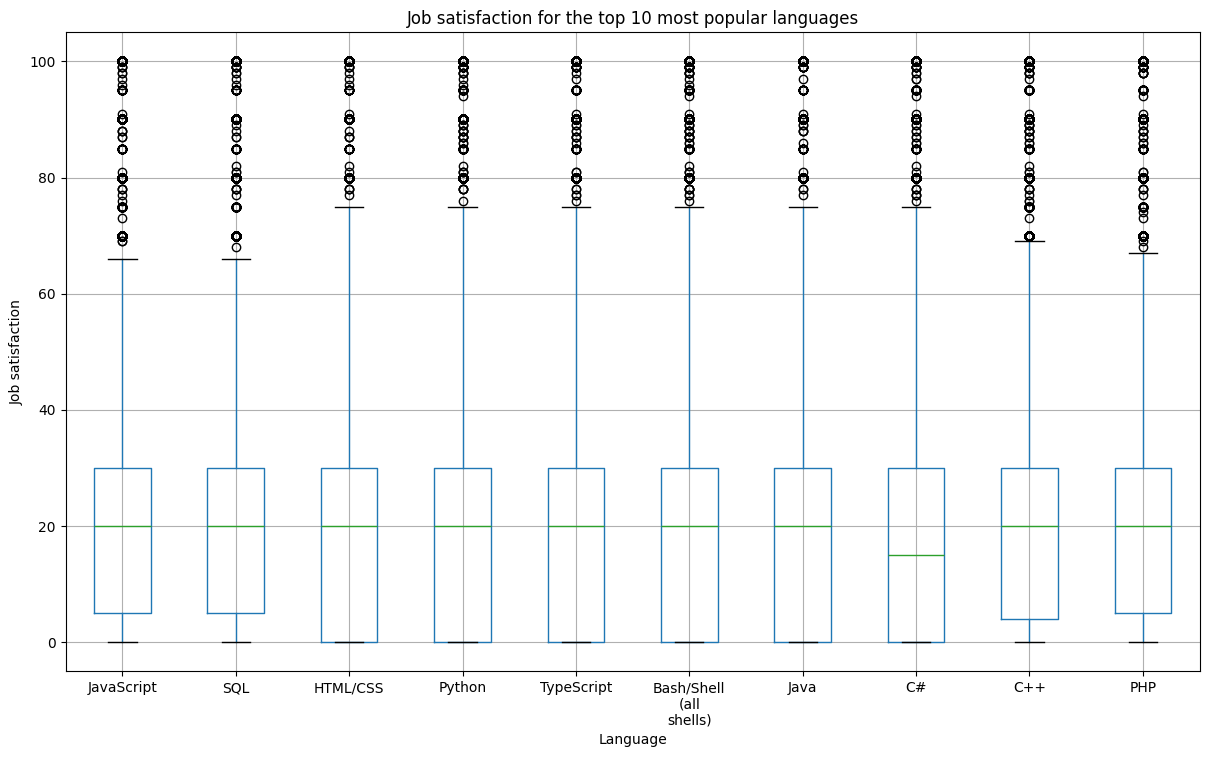

In [38]:
#let's plot the boxes for the top 10 languages using wrapped labels on x-axis
wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=10))
    for label in top_languages]
ax = filtered_df_lhww_js6.boxplot(column='JobSatPoints_6', by='Language', figsize=(12,8))
ax.set_xticklabels(wrapped_labels, ha='center')
plt.tight_layout()
plt.title("Job satisfaction for the top 10 most popular languages")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("Language")
plt.ylabel("Job satisfaction")
plt.show()

In [39]:
mean_js_by_lge = filtered_df_lhww_js6.groupby('Language').mean('JobSatPoints_5').sort_values(by='JobSatPoints_6', ascending=False).reset_index()
mean_js_by_lge

,Language,JobSatPoints_6
0,PHP,25.772770
1,Java,25.752243
2,TypeScript,25.327332
3,HTML/CSS,24.983012
4,JavaScript,24.932811
5,SQL,24.889480
6,C#,24.760905
7,C++,23.921340
8,Bash/Shell (all shells),23.237911
9,Python,22.974692


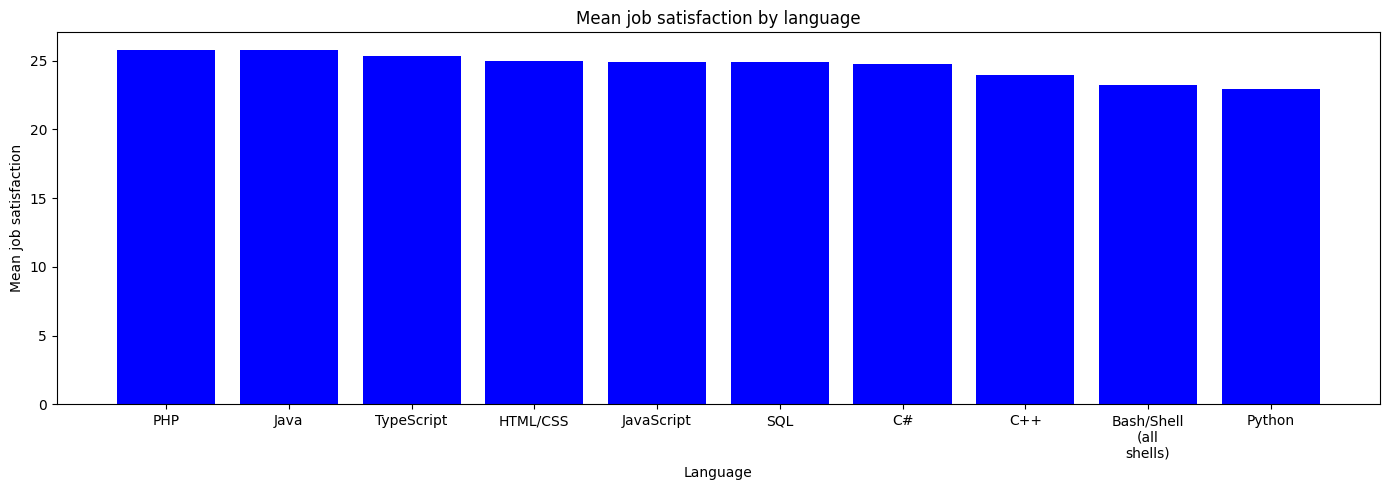

In [40]:
#visualization of mean job satisfaction by language using bar plot

# Wrap the labels
labels = [textwrap.fill(label, 10) for label in mean_js_by_lge['Language']] # 10 = max chars per line

plt.figure(figsize=(14, 5))
plt.bar(labels, mean_js_by_lge['JobSatPoints_6'] , color='blue')

plt.title('Mean job satisfaction by language')
plt.xlabel('Language')
plt.ylabel('Mean job satisfaction')

plt.xticks(rotation=0)  # rotation 0 now works fine with wrapped labels
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [41]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_js6_ep = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna()
print(df_ccy_js6_ep.shape)
df_ccy_js6_ep.head()

(16185, 3)


,ConvertedCompYearly,JobSatPoints_6,Employment
72,7322.0,65.0,"Employed, full-time;Student, full-time;Indepen..."
379,91295.0,0.0,"Employed, full-time"
389,110000.0,20.0,"Employed, full-time;Student, part-time"
392,161044.0,30.0,"Employed, full-time"
398,195000.0,30.0,"Employed, full-time"


In [42]:
#Employment is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_ccy_js6_ep = df_ccy_js6_ep.assign(EmpType=df_ccy_js6_ep['Employment'].str.split(';')).explode('EmpType')
df_ccy_js6_ep.head()

,ConvertedCompYearly,JobSatPoints_6,Employment,EmpType
72,7322.0,65.0,"Employed, full-time;Student, full-time;Indepen...","Employed, full-time"
72,7322.0,65.0,"Employed, full-time;Student, full-time;Indepen...","Student, full-time"
72,7322.0,65.0,"Employed, full-time;Student, full-time;Indepen...","Independent contractor, freelancer, or self-em..."
72,7322.0,65.0,"Employed, full-time;Student, full-time;Indepen...","Employed, part-time"
379,91295.0,0.0,"Employed, full-time","Employed, full-time"


In [43]:
df_ccy_js6_ep.nunique()

ConvertedCompYearly    4901
JobSatPoints_6           83
Employment               47
EmpType                   8
dtype: int64

In [44]:
df_ccy_js6_ep['ConvertedCompYearly'].describe()

count    1.906200e+04
mean     8.366633e+04
std      2.141408e+05
min      1.000000e+00
25%      3.000000e+04
50%      6.369400e+04
75%      1.057060e+05
max      1.381802e+07
Name: ConvertedCompYearly, dtype: float64

In [45]:
#let's exclude outliers of ConvertedCompYearly
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.057060e+05
q1 = 3.000000e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_ccy_js6_ep_no_outliers = df_ccy_js6_ep[df_ccy_js6_ep['ConvertedCompYearly']<=out_upper]
df_ccy_js6_ep_no_outliers.shape

IQR =  75706.0
Upper bound for outliers =  219265.0
Lower bound for outliers =  -83559.0


(18310, 4)

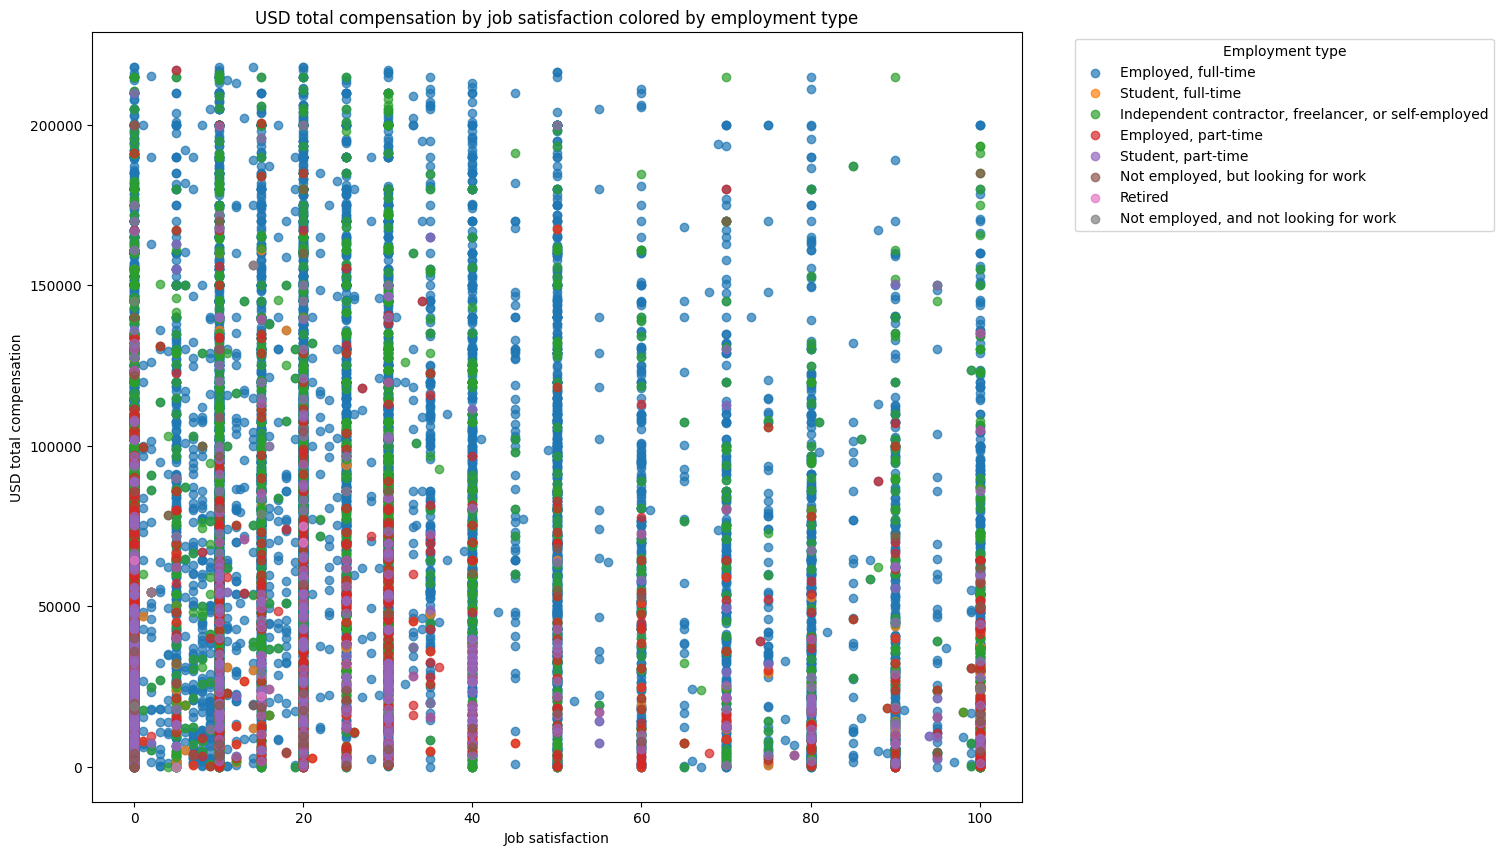

In [46]:
#let's plot the scatter plot
emp_types = df_ccy_js6_ep_no_outliers['EmpType'].unique()

plt.figure(figsize=(12, 10))

for et in emp_types:
    subset = df_ccy_js6_ep_no_outliers[df_ccy_js6_ep_no_outliers['EmpType'] == et]
    plt.scatter(
        subset['JobSatPoints_6'],
        subset['ConvertedCompYearly'],
        label=et,
        alpha=0.7
    )

plt.xlabel('Job satisfaction')
plt.ylabel('USD total compensation')
plt.title('USD total compensation by job satisfaction colored by employment type')
plt.legend(title='Employment type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


###Age is originally a categorical variable (age group, actually), not suited for a scatter plot; we will convert it to numeric, replacing the age group by its mean value. We will plot then the scatter plot using these means as age values.

In [47]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_ag_ct = df[['ConvertedCompYearly', 'Age', 'Country']].dropna()
print(df_ccy_ag_ct.shape)
df_ccy_ag_ct.head()

(23435, 3)


,ConvertedCompYearly,Age,Country
72,7322.0,18-24 years old,Pakistan
374,30074.0,25-34 years old,Austria
379,91295.0,35-44 years old,Turkey
385,53703.0,35-44 years old,France
389,110000.0,25-34 years old,United States of America


In [48]:
#Age is a categorical variable whose values are actually  age ranges. In order to plot  scatter plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and create another column with the age range mean values.
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_ccy_ag_ct_1 = df_ccy_ag_ct[df_ccy_ag_ct['Age'] != 'Prefer not to say'].copy()
df_ccy_ag_ct_1.loc[:, 'AgeRangeMean'] = df_ccy_ag_ct_1['Age'].map(numerical_ages)
df_ccy_ag_ct_1['AgeRangeMean'] = df_ccy_ag_ct_1['AgeRangeMean'].astype(float)
print(df_ccy_ag_ct_1.shape)
df_ccy_ag_ct_1.head()

(23426, 4)


,ConvertedCompYearly,Age,Country,AgeRangeMean
72,7322.0,18-24 years old,Pakistan,21.0
374,30074.0,25-34 years old,Austria,29.5
379,91295.0,35-44 years old,Turkey,39.5
385,53703.0,35-44 years old,France,39.5
389,110000.0,25-34 years old,United States of America,29.5


###We can do a better analysis by excluding ConvertedCompYearly outliers

In [49]:
df_ccy_ag_ct_1['ConvertedCompYearly'].describe()

count    2.342600e+04
mean     8.613250e+04
std      1.867864e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079370e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [50]:
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.079370e+05
q1 = 3.271200e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  75225.0
Upper bound for outliers =  220774.5
Lower bound for outliers =  -80125.5


In [51]:
df_ccy_ag_ct_1_no_outliers = df_ccy_ag_ct_1[df_ccy_ag_ct_1['ConvertedCompYearly']<=out_upper]
df_ccy_ag_ct_1_no_outliers.shape

(22449, 4)

In [52]:
df_ccy_ag_ct_1_no_outliers['Country'].nunique()

165

In [53]:
#We have too many countries, let's plot the chart considering the top 10 countries
top_countries = df_ccy_ag_ct_1_no_outliers['Country'].value_counts().head(10).index
filtered_df_ccy_ag_ct_1_no_outliers = df_ccy_ag_ct_1_no_outliers[df_ccy_ag_ct_1_no_outliers['Country'].isin(top_countries)]
print(top_countries)
filtered_df_ccy_ag_ct_1_no_outliers.head()

Index(['United States of America', 'Germany', 'Ukraine',
       'United Kingdom of Great Britain and Northern Ireland', 'India',
       'France', 'Canada', 'Brazil', 'Poland', 'Spain'],
      dtype='object', name='Country')


,ConvertedCompYearly,Age,Country,AgeRangeMean
385,53703.0,35-44 years old,France,39.5
389,110000.0,25-34 years old,United States of America,29.5
392,161044.0,35-44 years old,United Kingdom of Great Britain and Northern I...,39.5
395,121018.0,45-54 years old,United Kingdom of Great Britain and Northern I...,49.5
398,195000.0,45-54 years old,United States of America,49.5


In [54]:
#let's set a color table (for Country) 
countries = filtered_df_ccy_ag_ct_1_no_outliers['Country'].unique()
colors = dict(zip(countries, plt.cm.tab10.colors))
colors

{'France': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'United States of America': (1.0, 0.4980392156862745, 0.054901960784313725),
 'United Kingdom of Great Britain and Northern Ireland': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'Brazil': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'Germany': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'Ukraine': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'Canada': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'India': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 'Spain': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 'Poland': (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)}

In [55]:
#let's set marker table (for Age)
ages = sorted(filtered_df_ccy_ag_ct_1_no_outliers['AgeRangeMean'].unique().tolist())
markers = dict(zip(ages, ['o', 's', '^', 'v', 'D', 'x', '+']))
markers

{13.5: 'o', 21.0: 's', 29.5: '^', 39.5: 'v', 49.5: 'D', 59.5: 'x', 72.5: '+'}

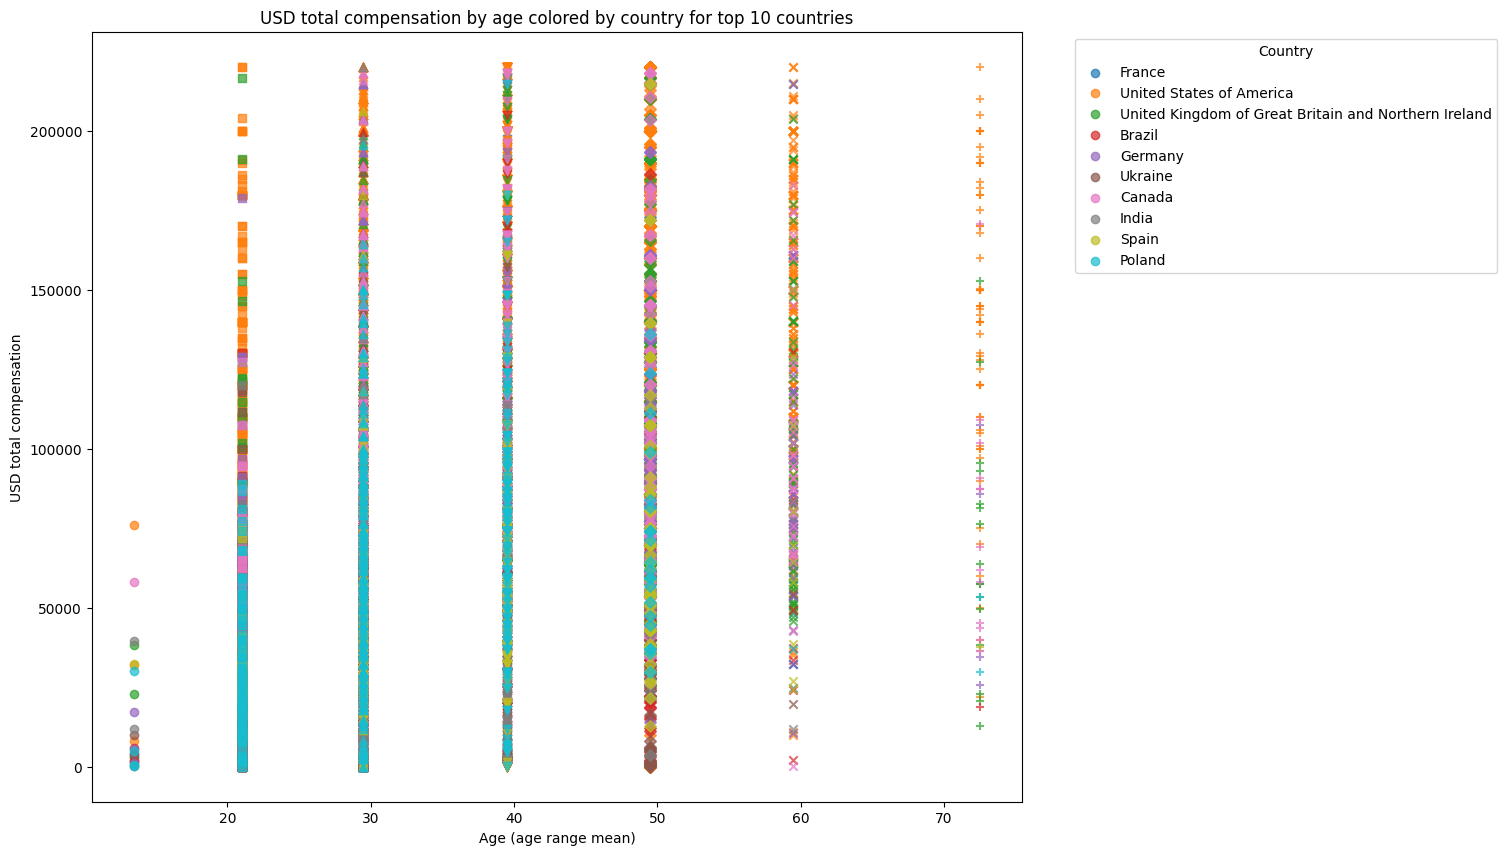

In [56]:
#let's plot the scatter plot

plt.figure(figsize=(12, 10))
labeled_countries = set()

for age in ages:
    for country in countries:
        subset = filtered_df_ccy_ag_ct_1_no_outliers[(filtered_df_ccy_ag_ct_1_no_outliers['Country'] == country) & (filtered_df_ccy_ag_ct_1_no_outliers['AgeRangeMean'] == age)]
         # Add label only once per country
        label = country if country not in labeled_countries else None
        labeled_countries.add(country)
        plt.scatter(
            subset['AgeRangeMean'],
            subset['ConvertedCompYearly'],
            label=label,
            color=colors[country],
            marker=markers[age],
            alpha=0.7
                   )

plt.xlabel('Age (age range mean)')
plt.ylabel('USD total compensation')
plt.title('USD total compensation by age colored by country for top 10 countries')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

###To have a better visualization of the relationship among these three variables, I think a bar chart of total USD compensation by age group and country will be better, let's do it

In [57]:
#let's group the data by Age and Country and calculate mean compensation by each group
grouped = (filtered_df_ccy_ag_ct_1_no_outliers.groupby(['Age', 'Country'], as_index=False)['ConvertedCompYearly'].mean())
print(type(grouped))
grouped.head()

<class 'pandas.core.frame.DataFrame'>


,Age,Country,ConvertedCompYearly
0,18-24 years old,Brazil,13149.637795
1,18-24 years old,Canada,50467.929293
2,18-24 years old,France,34486.140741
3,18-24 years old,Germany,36447.118467
4,18-24 years old,India,12344.888525


In [58]:
pivot = grouped.pivot(index='Age', columns='Country', values='ConvertedCompYearly')
pivot.head()

Country,Brazil,Canada,France,Germany,India,Poland,Spain,Ukraine,United Kingdom of Great Britain and Northern Ireland,United States of America
Age,,,,,,,,,,
18-24 years old,13149.637795,50467.929293,34486.140741,36447.118467,12344.888525,28506.216981,28945.468750,18842.780679,56120.448276,88332.409201
25-34 years old,33966.040123,87666.943787,57837.920455,70489.218681,25988.403604,61538.717857,50224.820513,40285.914246,85424.102410,124844.532616
35-44 years old,50289.373418,101524.659751,72808.601732,86780.855615,39468.583893,75034.244048,67227.895954,37707.745161,98955.986842,142200.279857
45-54 years old,38848.071429,107398.123810,74075.023256,96050.620321,45996.000000,68614.333333,72611.000000,33311.711111,103165.015075,145637.415861
55-64 years old,56650.666667,101011.205128,77395.588235,96026.764706,51841.333333,37120.000000,74948.100000,37026.000000,100116.469880,143864.331034


In [59]:
#let's make some changes to column names to make things easier...
pivot.rename(columns={'United Kingdom of Great Britain and Northern Ireland': 'UK', 'United States of America': 'USA'}, inplace=True)
pivot.head()

Country,Brazil,Canada,France,Germany,India,Poland,Spain,Ukraine,UK,USA
Age,,,,,,,,,,
18-24 years old,13149.637795,50467.929293,34486.140741,36447.118467,12344.888525,28506.216981,28945.468750,18842.780679,56120.448276,88332.409201
25-34 years old,33966.040123,87666.943787,57837.920455,70489.218681,25988.403604,61538.717857,50224.820513,40285.914246,85424.102410,124844.532616
35-44 years old,50289.373418,101524.659751,72808.601732,86780.855615,39468.583893,75034.244048,67227.895954,37707.745161,98955.986842,142200.279857
45-54 years old,38848.071429,107398.123810,74075.023256,96050.620321,45996.000000,68614.333333,72611.000000,33311.711111,103165.015075,145637.415861
55-64 years old,56650.666667,101011.205128,77395.588235,96026.764706,51841.333333,37120.000000,74948.100000,37026.000000,100116.469880,143864.331034


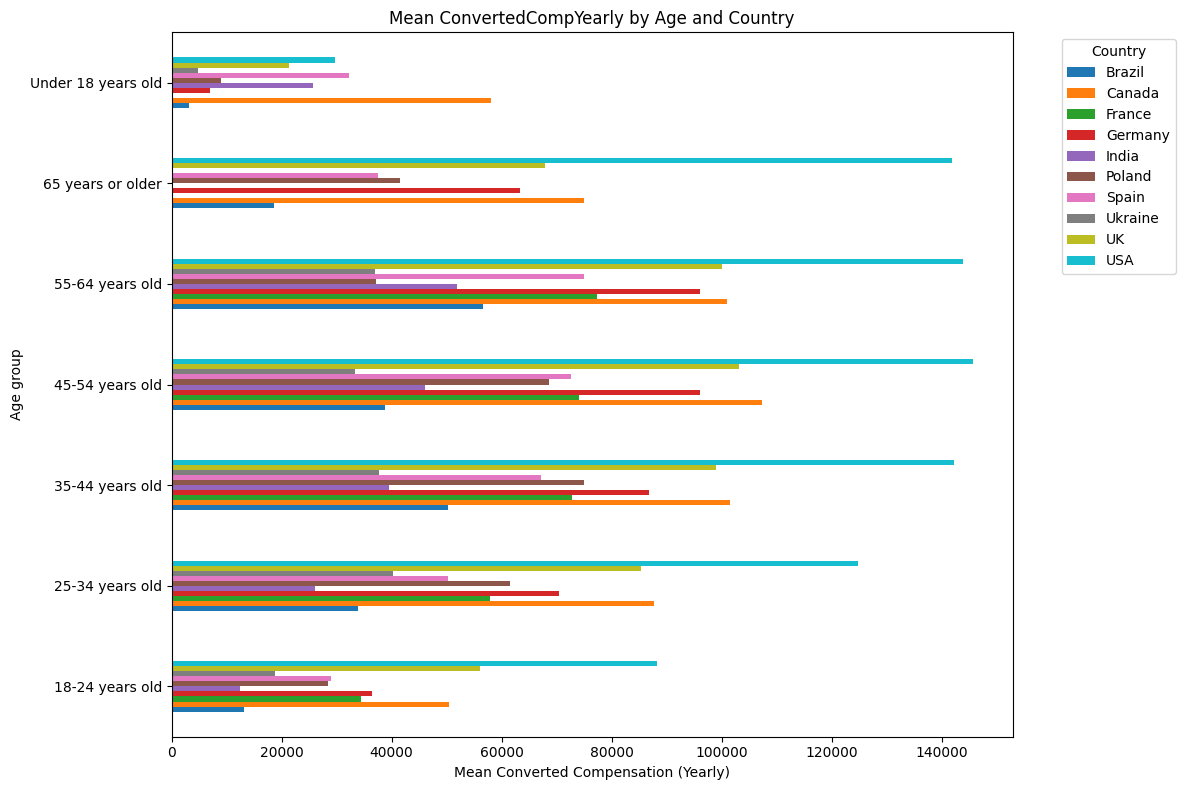

In [60]:
pivot.plot(
    kind='barh',
    figsize=(12, 8)
)

plt.xlabel('Mean Converted Compensation (Yearly)')
plt.ylabel('Age group')
plt.title('Mean ConvertedCompYearly by Age and Country')

plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
